# 导入必要的库

In [2]:
import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# 设置随机种子，保证每次运行划分的数据是一样的（可复现性）
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print("库加载完成，随机种子已设置。")

库加载完成，随机种子已设置。


#  读取数据，划分数据

确保数据的路径是

```txt
data/
    ├─georges
    └─non_georges
```

In [3]:
# 定义数据文件夹路径
DATA_DIR = "./data"
POS_DIR = os.path.join(DATA_DIR, "georges")
NEG_DIR = os.path.join(DATA_DIR, "non_georges")


# 获取所有图片的完整路径，并打上标签（1 代表正类，0 代表负类）
def get_image_paths_and_labels(folder_path, label):
    # 过滤出图片文件，防止混入隐藏文件如 .DS_Store
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    return [(os.path.join(folder_path, f), label) for f in os.listdir(folder_path) 
            if f.lower().endswith(valid_extensions)]

pos_data = get_image_paths_and_labels(POS_DIR, 1)
neg_data = get_image_paths_and_labels(NEG_DIR, 0)

all_data = pos_data + neg_data
all_paths = [item[0] for item in all_data]
all_labels = [item[1] for item in all_data]

print(f"总数据量: {len(all_paths)} (正类: {len(pos_data)}, 负类: {len(neg_data)})")


# 第一次划分：分出 70% 作为训练集，30% 留给验证和测试
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=0.3, stratify=all_labels, random_state=42
)


# 第二次划分：将剩下的 30% 平分，得到 15% 验证集和 15% 测试集
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

print(f"训练集大小: {len(train_paths)}")
print(f"验证集大小: {len(val_paths)}")
print(f"测试集大小: {len(test_paths)}")

总数据量: 5700 (正类: 2360, 负类: 3340)
训练集大小: 3990
验证集大小: 855
测试集大小: 855


# 数据增强（Transforms）

In [4]:
# ImageNet 的标准均值和标准差
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# 训练集的数据增强：增加各种随机干扰
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),               # 先放大一点
    transforms.RandomResizedCrop(224),           # 随机裁剪到 224x224
    transforms.RandomHorizontalFlip(p=0.5),      # 一半的概率水平翻转
    transforms.RandomRotation(degrees=15),       # 随机旋转最多 15 度
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # 稍微改变亮度和对比度
    transforms.ToTensor(),                       # 转换成 PyTorch 需要的张量 (Tensor)
    transforms.Normalize(mean, std)              # 标准化
])


# 验证集和测试集的处理：不能有随机干扰，只有基础缩放和标准化
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),               # 直接缩放到 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# 自定义 PyTorch Dataset

In [5]:
class SaintGeorgeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        # 返回数据集的总长度
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 根据索引 idx 获取一张图片和它的标签
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # 使用 PIL 打开图片。统一转成 RGB 防报错。
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"读取图片失败: {img_path}. 错误: {e}")
            image = Image.new('RGB', (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.float32)

# 实例化三个数据集
train_dataset = SaintGeorgeDataset(train_paths, train_labels, transform=train_transforms)
val_dataset = SaintGeorgeDataset(val_paths, val_labels, transform=val_test_transforms)
test_dataset = SaintGeorgeDataset(test_paths, test_labels, transform=val_test_transforms)

print("数据集实例化完成。数据划分核对如下：")
print(f"  - 训练集装载了: {len(train_dataset)} 张图片")
print(f"  - 验证集装载了: {len(val_dataset)} 张图片")
print(f"  - 测试集装载了: {len(test_dataset)} 张图片")

数据集实例化完成。数据划分核对如下：
  - 训练集装载了: 3990 张图片
  - 验证集装载了: 855 张图片
  - 测试集装载了: 855 张图片


# 创建 DataLoader 并在 Jupyter 中进行可视化验证


todo :

把这些超参数都放在一起，算是比较成熟的做法。容易找到，因为经常修改。

In [7]:
# 这个参数，# 这个需要根据自己的硬件来。我的是  12G 显存

#BATCH_SIZE = 32 # 此时gpu占用 3.2G
BATCH_SIZE=128   # 此时gpu占用 7.2G

# 创建 DataLoader
# 注意：在 Windows+Jupyter 环境下，num_workers 必须设为 0，否则会引发多进程寻址报错
NUM_WORKERS = 0


# 2. 核心优化：加入 pin_memory=True 极大地提升 CPU 到 GPU 的数据传输速度
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS, 
    pin_memory=True,     # 开启专属显存通道
    drop_last=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=True      # 开启专属显存通道
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=True
)

print(f"数据加载器已更新: BATCH_SIZE = {BATCH_SIZE}, PIN_MEMORY = True")

数据加载器已更新: BATCH_SIZE = 128, PIN_MEMORY = True


# 查看一个图片。

正在从 DataLoader 中抽取一批数据进行可视化...


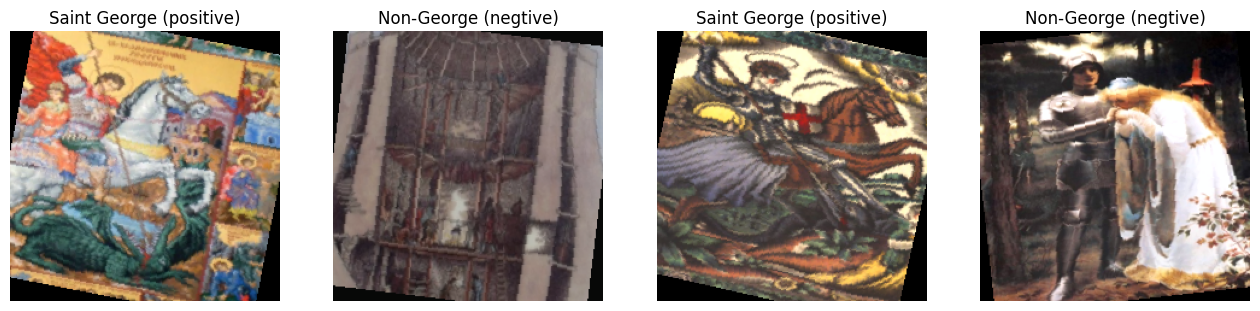

可视化完成！如果你能看到图片，说明数据准备阶段完美结束。


In [8]:

# 可视化一个 Batch 的函数
def imshow(inp, title=None):
    """反归一化并展示图片"""
    inp = inp.numpy().transpose((1, 2, 0)) # 将 PyTorch 的 (C, H, W) 转成 matplotlib 需要的 (H, W, C)
    mean_np = np.array(mean)
    std_np = np.array(std)
    inp = std_np * inp + mean_np # 反归一化
    inp = np.clip(inp, 0, 1)     # 限制像素值在 0 到 1 之间
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')

print("正在从 DataLoader 中抽取一批数据进行可视化...")

# 从训练集加载器中拿出一个批次的数据
images, labels = next(iter(train_loader))

# 展示前 4 张图片
fig = plt.figure(figsize=(16, 4))
for i in range(4):
    ax = fig.add_subplot(1, 4, i+1)
    label_name = "Saint George (positive)" if labels[i].item() == 1.0 else "Non-George (negtive)"
    imshow(images[i], title=label_name)

plt.show()
print("可视化完成！如果你能看到图片，说明数据准备阶段完美结束。")

# 构建迁移学习模型  ResNet18

In [9]:
import torchvision.models as models
import torch.nn as nn

def build_model():
    # 1. 请来老侦探：加载预训练的 ResNet18 模型
    # weights=models.ResNet18_Weights.DEFAULT 表示使用在 ImageNet 上训练好的最优权重
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    # 获取老侦探最后输出前的特征数量（ResNet18 是 512）
    num_ftrs = model.fc.in_features
    
    # 2. 换脑手术：把原本输出 1000 个类别的全连接层 (fc)，替换成只输出 1 个数值的层
    # 输出的这 1 个数值越大，代表是圣乔治的概率越高；越小代表越不是。
    model.fc = nn.Linear(num_ftrs, 1)
    
    return model

model = build_model()
print("ResNet18 模型构建完成，最后的分类层已替换为二分类。")

ResNet18 模型构建完成，最后的分类层已替换为二分类。


# 配置训练三剑客（gpu、损失函数、优化器）

In [10]:
import torch.optim as optim

# 1. 自动选择硬件设备（如果有 NVIDIA 显卡就用 GPU，否则用 CPU）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"当前使用的计算设备是: {device}")

# 2. 计算正样本权重以解决数据不平衡
# 负样本数量 3340，正样本数量 2360
# 权重 = 负样本总数 / 正样本总数
weight_value = 3340 / 2360
pos_weight = torch.tensor([weight_value]).to(device)

# 3. 定义损失函数 (BCEWithLogitsLoss 内置了 Sigmoid，数值计算更稳定)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# 4. 定义优化器
# 学习率设为 0.0001 (1e-4)，因为老侦探已经很有经验了，我们只需要他小步微调，不能步子太大把原有记忆忘光
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

print(f"正类惩罚权重设置为: {weight_value:.2f}")
print("损失函数与优化器配置完成。")

当前使用的计算设备是: cuda
正类惩罚权重设置为: 1.42
损失函数与优化器配置完成。


# 加载已经训练过的模型

In [11]:
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from pathlib import Path

# ====================== 1. 直接加载最佳模型 ======================
def load_best_model(model_path="resnet18_best.pth", num_classes=2):
    print(f"正在从磁盘加载最佳模型: {model_path}")
    
    # 重新构建模型结构（必须和训练时一致）
    model = build_model()                    # ← 确保这个函数和你训练时用的一致
    model = model.to(device)
    
    # 加载权重
    checkpoint = torch.load(model_path, map_location=device)
    
    # 兼容两种常见保存方式
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"成功加载模型！（保存于 epoch {checkpoint.get('epoch', '未知')}）")
    else:
        # 直接保存整个模型的情况
        model.load_state_dict(checkpoint)
        print("成功加载模型！（直接保存的完整模型）")
    
    model.eval()
    print(f"模型已切换到评估模式 (eval)")
    
    return model


# ====================== 2. 加载模型 ======================
best_model = load_best_model(
    model_path="resnet18_best.pth",   # 如果路径不同，请修改这里
    num_classes=2
)

正在从磁盘加载最佳模型: resnet18_best.pth
成功加载模型！（直接保存的完整模型）
模型已切换到评估模式 (eval)


# 计算预测结果

In [14]:
# !pip install seaborn

正在加载最终模型权重: resnet18_best.pth ...
正在测试集上进行全面推理...


Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]


最终分类报告 (Classification Report):
                  precision    recall  f1-score   support

  Non-George (0)     0.9210    0.9541    0.9373       501
Saint George (1)     0.9315    0.8842    0.9072       354

        accuracy                         0.9251       855
       macro avg     0.9263    0.9191    0.9223       855
    weighted avg     0.9254    0.9251    0.9248       855

ROC AUC Score: 0.9676


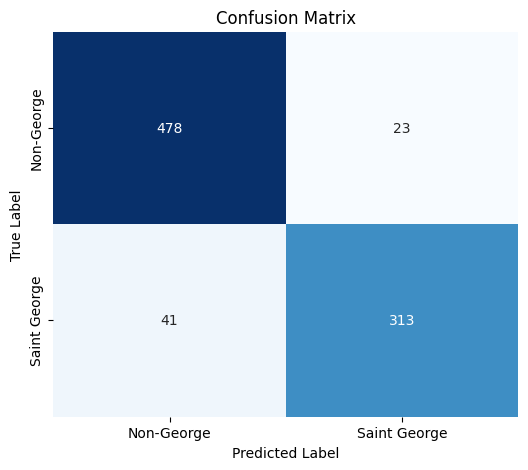

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns

def evaluate_final_model(model_path, test_loader):
    print(f"正在加载最终模型权重: {model_path} ...")
    # 1. 加载模型
    final_model = build_model().to(device)
    final_model.load_state_dict(torch.load(model_path))
    final_model.eval()
    
    all_preds = []
    all_probs = []
    all_labels = []
    
    print("正在测试集上进行全面推理...")
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Evaluating"):
            inputs = inputs.to(device)
            outputs = final_model(inputs)
            
            # 获取概率和预测类别
            probs = torch.sigmoid(outputs).squeeze().cpu().numpy()
            # 如果 batch_size=1，probs 可能是个标量，需要转成数组
            if probs.ndim == 0:
                probs = np.expand_dims(probs, axis=0)
                
            preds = (probs >= 0.5).astype(int)
            
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    
    # 2. 计算各项指标
    print("\n" + "="*40)
    print("最终分类报告 (Classification Report):")
    print("="*40)
    # target_names: 0是负类，1是正类
    print(classification_report(all_labels, all_preds, target_names=['Non-George (0)', 'Saint George (1)'], digits=4))
    
    roc_auc = roc_auc_score(all_labels, all_probs)
    print(f"ROC AUC Score: {roc_auc:.4f}")
    
    # 3. 绘制混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Non-George', 'Saint George'],
                yticklabels=['Non-George', 'Saint George'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# 请确保文件名与你之前保存的高分模型文件名一致
# 如果你没改名字，应该是 "resnet18_best.pth" 或者 "best_model.pth"
evaluate_final_model("resnet18_best.pth", test_loader)

# 查找错误的图片。

In [22]:
import torch
import matplotlib.pyplot as plt
import shutil
from pathlib import Path
from tqdm.notebook import tqdm


def analyze_and_export_errors(model, test_dataset, test_loader, 
                              output_dir="error_analysis", 
                              threshold=0.5, 
                              max_show=8):
    """
    1. 分析测试集上的所有错误样本
    2. 把所有错图导出到本地文件夹
    3. 在 notebook 中展示最多 max_show 张错图
    """
    model.eval()
    device = next(model.parameters()).device
    
    # 创建输出文件夹
    out_path = Path(output_dir)
    fp_dir = out_path / "false_positives_普通图_误判为_乔治"
    fn_dir = out_path / "false_negatives_乔治_漏判为_普通"
    
    # 清空旧文件夹，重新创建
    if out_path.exists():
        shutil.rmtree(out_path)
    
    fp_dir.mkdir(parents=True, exist_ok=True)
    fn_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"开始错误分析，并将错图导出到: {out_path.absolute()}")
    
    misclassified_count = 0
    show_images = []
    show_true_labels = []
    show_pred_probs = []
    
    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(tqdm(test_loader, desc="Analyzing errors")):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            probs = torch.sigmoid(outputs).squeeze().cpu()
            preds = (probs >= threshold).int()
            
            # 处理当前 batch 中的每一个样本
            for i in range(len(labels)):
                true_label = int(labels[i].item())      # 0: 普通图, 1: 乔治
                pred_label = int(preds[i].item())
                prob_val = probs[i].item()
                
                if true_label != pred_label:
                    misclassified_count += 1
                    
                    # 获取原始图片路径并复制文件
                    if hasattr(test_dataset, 'image_paths'):
                        global_idx = batch_idx * test_loader.batch_size + i
                        if global_idx < len(test_dataset.image_paths):
                            img_path = Path(test_dataset.image_paths[global_idx])
                            img_name = img_path.name
                            
                            # 新文件名：包含真实标签、预测标签、概率
                            new_name = f"true{true_label}_pred{pred_label}_prob{prob_val:.3f}_{img_name}"
                            
                            if true_label == 0 and pred_label == 1:
                                # False Positive
                                shutil.copy2(img_path, fp_dir / new_name)
                            elif true_label == 1 and pred_label == 0:
                                # False Negative
                                shutil.copy2(img_path, fn_dir / new_name)
                    
                    # 收集用于显示的图片（最多 max_show 张）
                    if len(show_images) < max_show:
                        show_images.append(inputs[i].cpu())
                        show_true_labels.append(true_label)
                        show_pred_probs.append(prob_val)
    
    # ====================== 打印结果总结 ======================
    print(f"\n错误分析完成！共发现 {misclassified_count} 张分错的图片")
    print(f"False Positives (普通图误判为乔治) 保存在: {fp_dir}")
    print(f"False Negatives (乔治漏判为普通) 保存在: {fn_dir}")
    
    # ====================== 在 notebook 中显示最多 8 张错图 ======================
    if len(show_images) > 0:
        print(f"\n下面展示前 {len(show_images)} 张错误样本：")
        fig = plt.figure(figsize=(16, 8))
        
        for i in range(len(show_images)):
            ax = fig.add_subplot(2, 4, i + 1)
            
            # 显示图片（假设你已有 imshow 函数，如果没有可替换）
            imshow(show_images[i])
            
            true_str = "George" if show_true_labels[i] == 1 else "Non-George"
            pred_str = "George" if show_pred_probs[i] >= 0.5 else "Non-George"
            
            title = f"True: {true_str}\nPred: {pred_str}\nProb: {show_pred_probs[i]:.3f}"
            ax.set_title(title, color="red")
            ax.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("本次测试集中没有发现错误样本。")
    
    return misclassified_count



开始错误分析，并将错图导出到: C:\Users\Administrator\Code\binary-image-classification\error_analysis


Analyzing errors:   0%|          | 0/7 [00:00<?, ?it/s]


错误分析完成！共发现 64 张分错的图片
False Positives (普通图误判为乔治) 保存在: error_analysis\false_positives_普通图_误判为_乔治
False Negatives (乔治漏判为普通) 保存在: error_analysis\false_negatives_乔治_漏判为_普通

下面展示前 8 张错误样本：


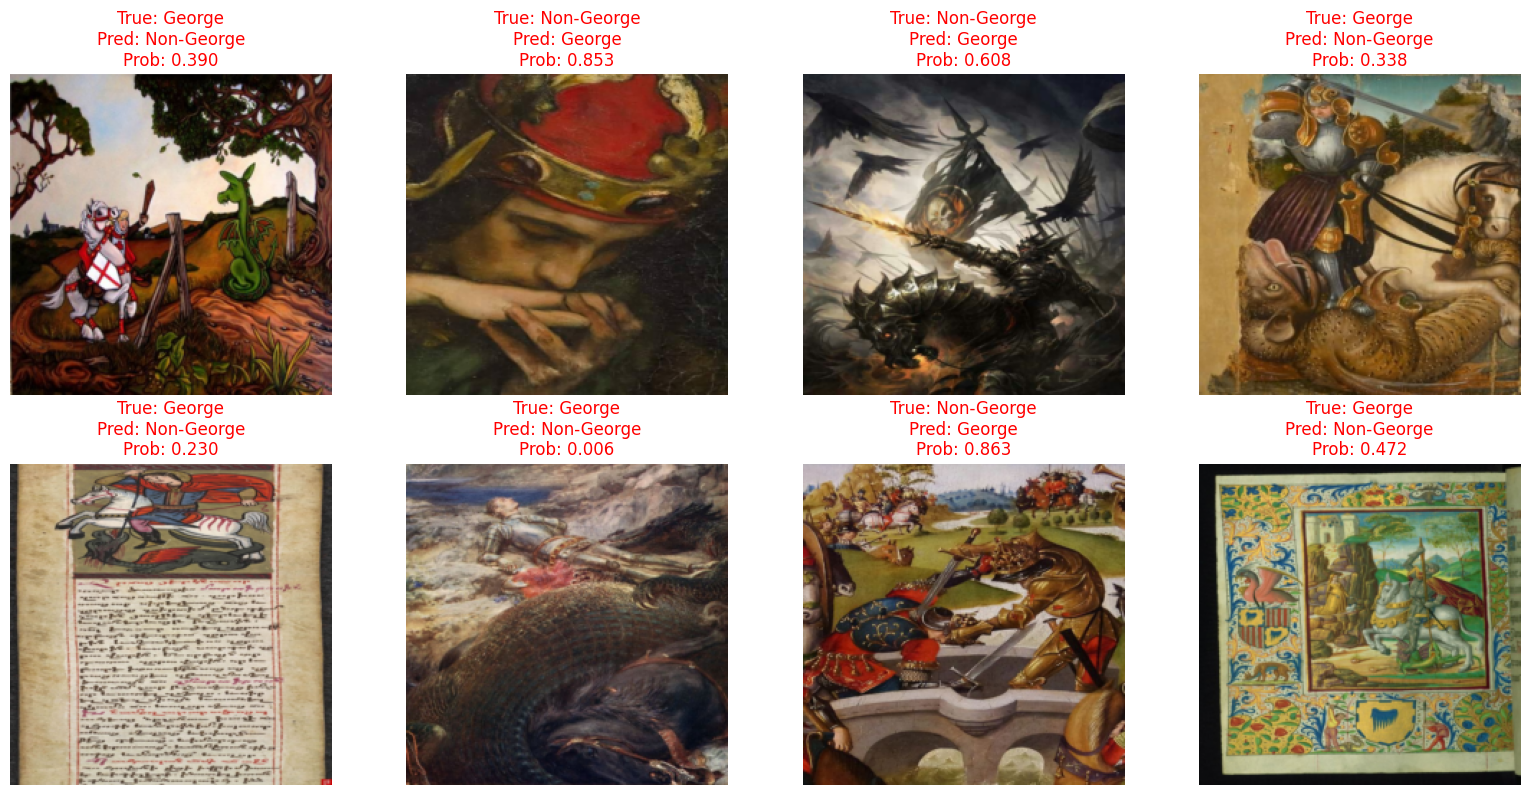

64

In [23]:

# ====================== 使用方法 ======================
# 直接调用下面这行即可（模型必须已经加载好）
analyze_and_export_errors(
    model=best_model,
    test_dataset=test_dataset,      # 必须包含 image_paths 属性
    test_loader=test_loader,
    output_dir="error_analysis",    # 可以改成你想要的文件夹名
    threshold=0.5,
    max_show=8
)

# 查看的过程，我发现：

## false_positives_普通图_误判为_乔治 23个
- 错误是有原因的，比如出现了，人物骑马，兵器，战斗这些很接近的元素。
- 甚至有一个，我觉得本身就是乔治斩龙，因为 人 + 马 + 剑 +  龙， 如下图

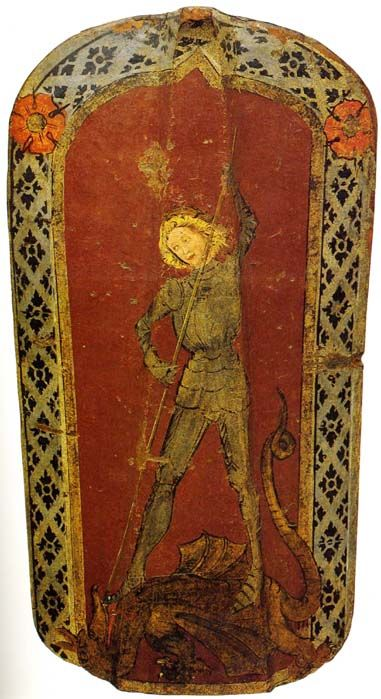




## false_negatives_乔治_漏判为_普通  41个

### 1. 有些图片显然不是 乔治， 大概是10个

### 2 有些是真的 乔治 30个


### 另外，甚至数据集中，出现了重复的数据！


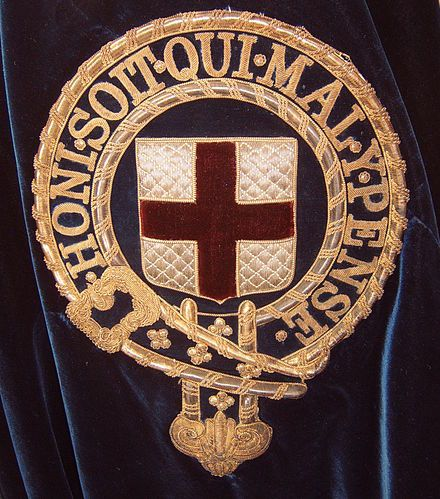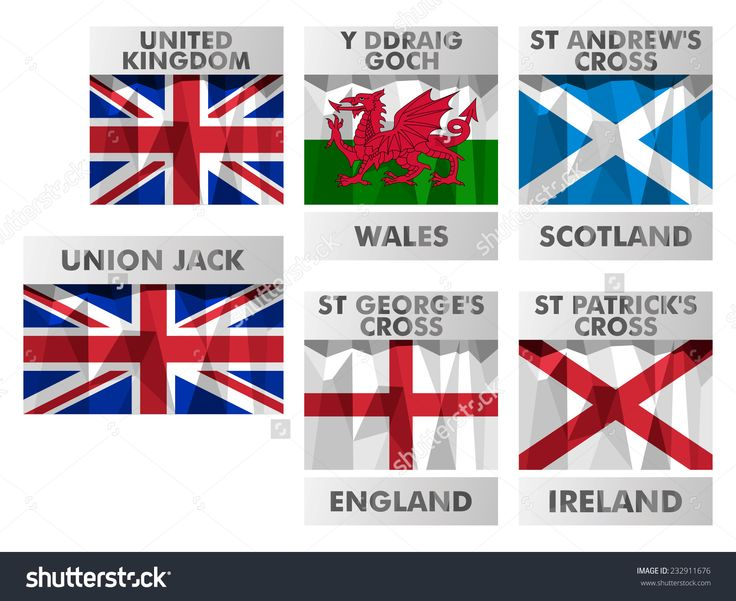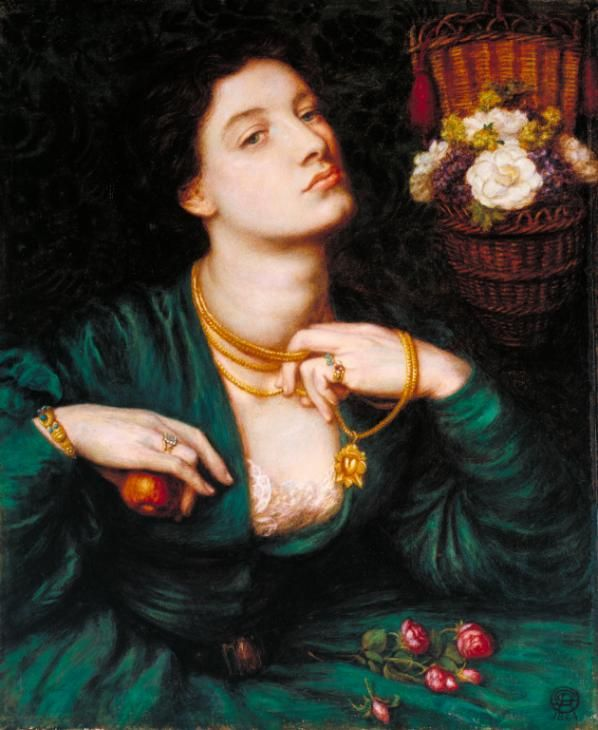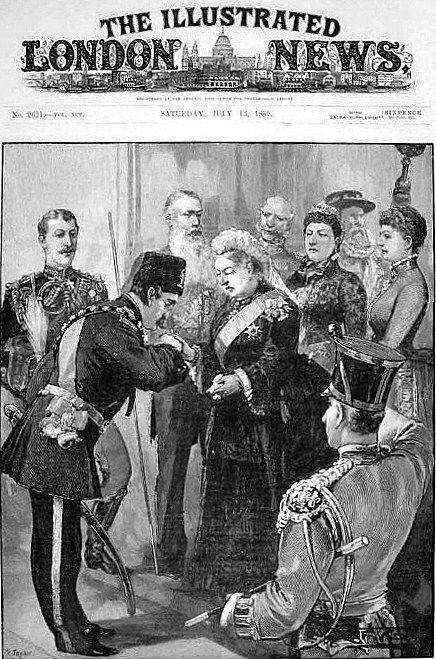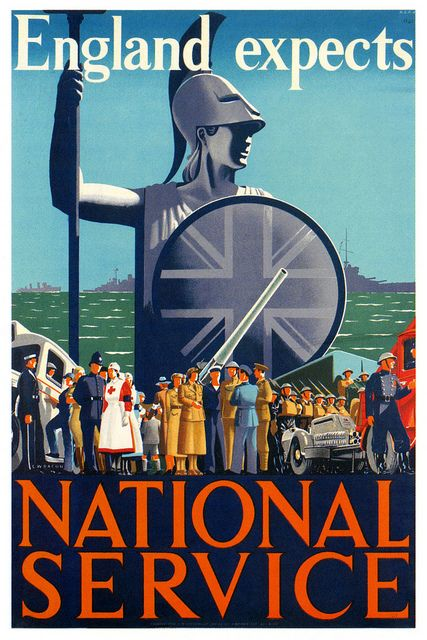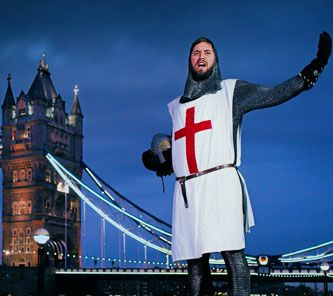

### 3. 有些是真的 乔治

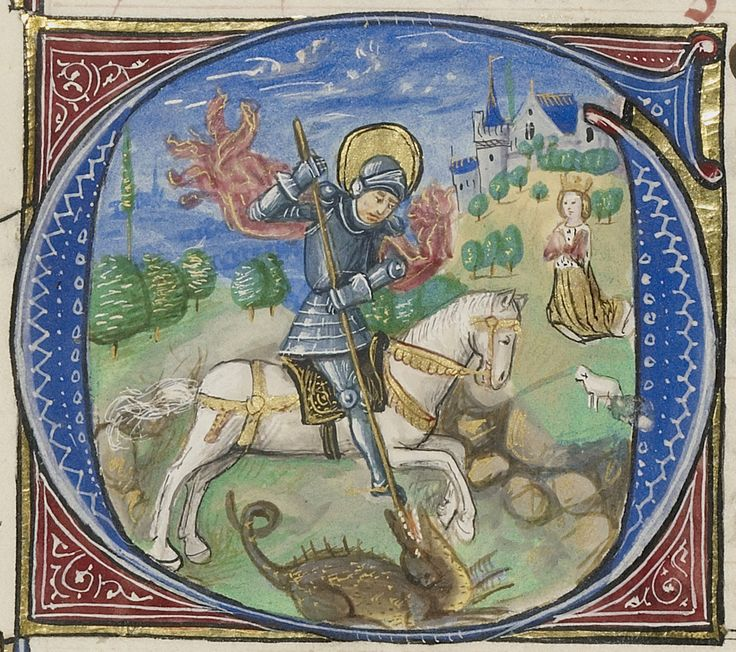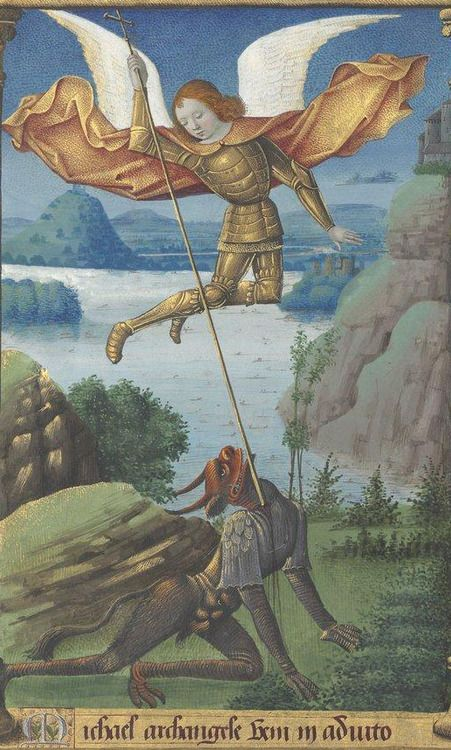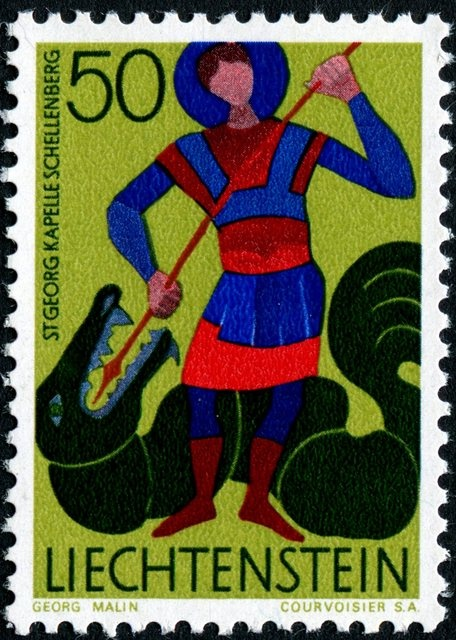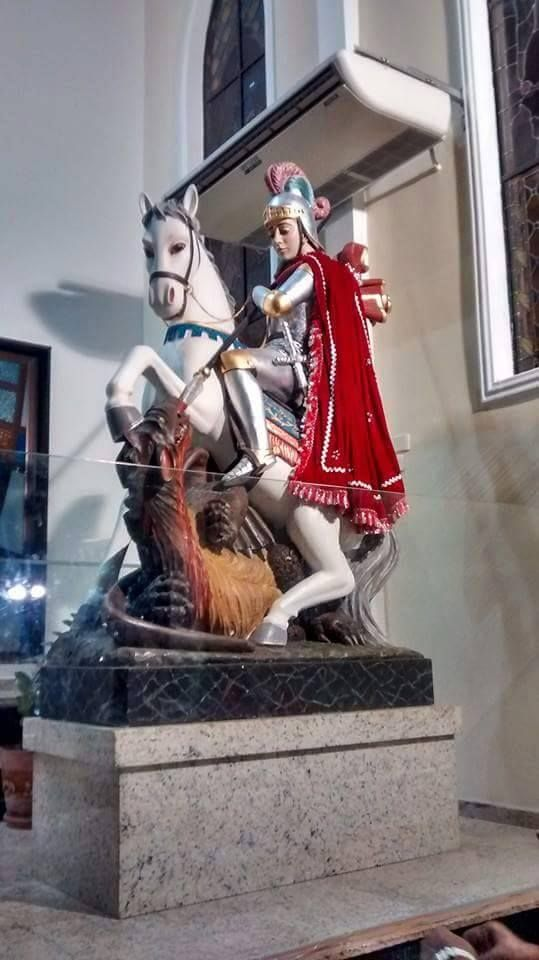

# 查看的过程，我发现：

## false_positives_普通图_误判为_乔治 23个
- 错误是有原因的，比如出现了，人物骑马，兵器，战斗这些很接近的元素。
- 甚至有一个，我觉得本身就是乔治斩龙，因为 人 + 马 + 剑 +  龙，  



## false_negatives_乔治_漏判为_普通  41个

### 1. 有些图片显然不是 乔治， 大概是10个

### 2 有些是真的 乔治 30个

### 3. 有些是真的 乔治

### 另外，甚至数据集中，出现了重复的数据！